In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering Algorithms
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.cluster import Birch
from sklearn.mixture import GaussianMixture

# Evaluation Metrics
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load data
df = pd.read_csv('Dry_Bean.csv')

print(df.shape)
df.head()

(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
df['Class'].value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


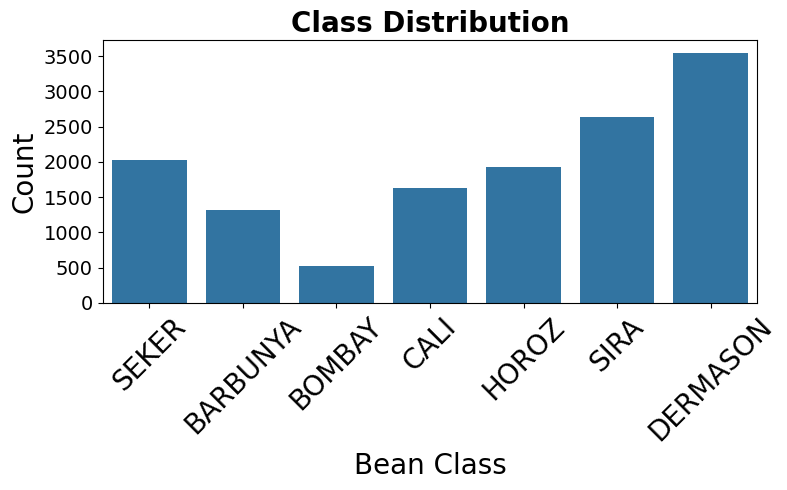

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='Class', data=df)

plt.title('Class Distribution', fontsize=20, fontweight='bold')
plt.xlabel('Bean Class', fontsize=20)
plt.ylabel('Count', fontsize=20)

plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=14)

plt.tight_layout()

plt.savefig('class_distribution1.png',
            dpi=600,
            bbox_inches='tight')

plt.show()

In [ ]:
X = df.drop('Class', axis=1)

y_actual = df['Class']

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:",
      pca.explained_variance_ratio_.sum())

Explained Variance: 0.8189741181790011


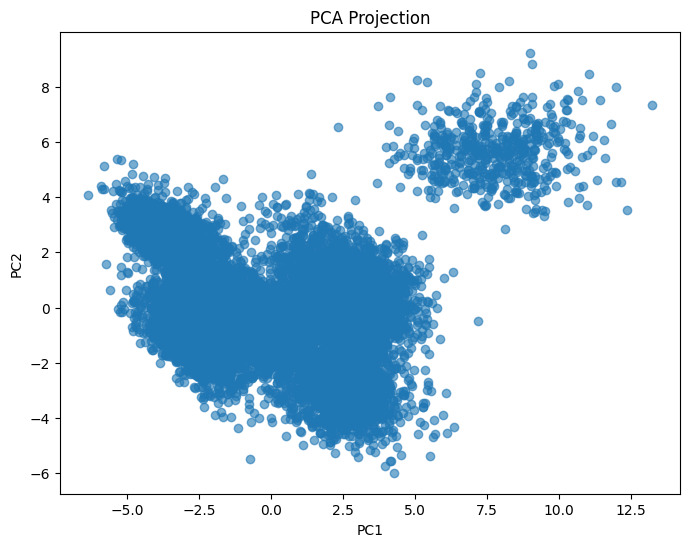

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.6
)

plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

In [ ]:
wcss = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_train)

    wcss.append(km.inertia_)

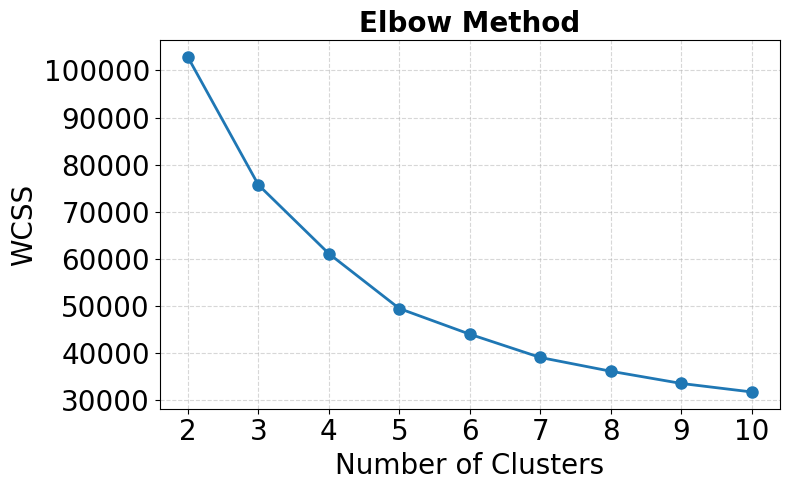

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11),
         wcss,
         marker='o',
         markersize=8,
         linewidth=2)

plt.title("Elbow Method",
          fontsize=20,
          fontweight='bold')

plt.xlabel("Number of Clusters",
           fontsize=20)

plt.ylabel("WCSS",
           fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('Elbow_Method1.png',
            dpi=600,
            bbox_inches='tight')

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_train)

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=7
)

agg_labels = agg.fit_predict(X_train)

In [ ]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_train)

In [ ]:
gmm = GaussianMixture(
    n_components=7,
    random_state=42
)

gmm.fit(X_train)

gmm_labels = gmm.predict(X_train)

In [ ]:
def evaluate_clusters(X, labels, model_name):

    if len(np.unique(labels)) < 2:
        return None

    return {
        "Model": model_name,
        "Silhouette": silhouette_score(X, labels),
        "Calinski_Harabasz":
            calinski_harabasz_score(X, labels),
        "Davies_Bouldin":
            davies_bouldin_score(X, labels)
    }

In [ ]:
birch = Birch(
    n_clusters=7
)

birch_labels = birch.fit_predict(X_train)

In [ ]:
def evaluate_clusters(X, labels, model_name):

    if len(np.unique(labels)) < 2:
        return None

    return {
        "Model": model_name,
        "Silhouette": silhouette_score(X, labels),
        "Calinski_Harabasz":
            calinski_harabasz_score(X, labels),
        "Davies_Bouldin":
            davies_bouldin_score(X, labels)
    }

In [ ]:
results = []

for labels, name in [

    (kmeans_labels, "KMeans"),
    (agg_labels, "Agglomerative"),
    (dbscan_labels, "DBSCAN"),
    (birch_labels, "Birch"),
    (gmm_labels, "GMM")

]:

    score = evaluate_clusters(
        X_train,
        labels,
        name
    )

    if score:
        results.append(score)

results_df = pd.DataFrame(results)

results_df

,Model,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,KMeans,0.309035,6219.925181,1.099351
1,Agglomerative,0.262228,5562.257751,1.247731
2,DBSCAN,0.148090,858.783035,1.330565
3,Birch,0.322353,5277.531610,1.115049
4,GMM,0.289714,5107.094208,1.665191


In [ ]:
results_df.sort_values(
    by='Silhouette',
    ascending=False
)

,Model,Silhouette,Calinski_Harabasz,Davies_Bouldin
3,Birch,0.322353,5277.531610,1.115049
0,KMeans,0.309035,6219.925181,1.099351
4,GMM,0.289714,5107.094208,1.665191
1,Agglomerative,0.262228,5562.257751,1.247731
2,DBSCAN,0.148090,858.783035,1.330565


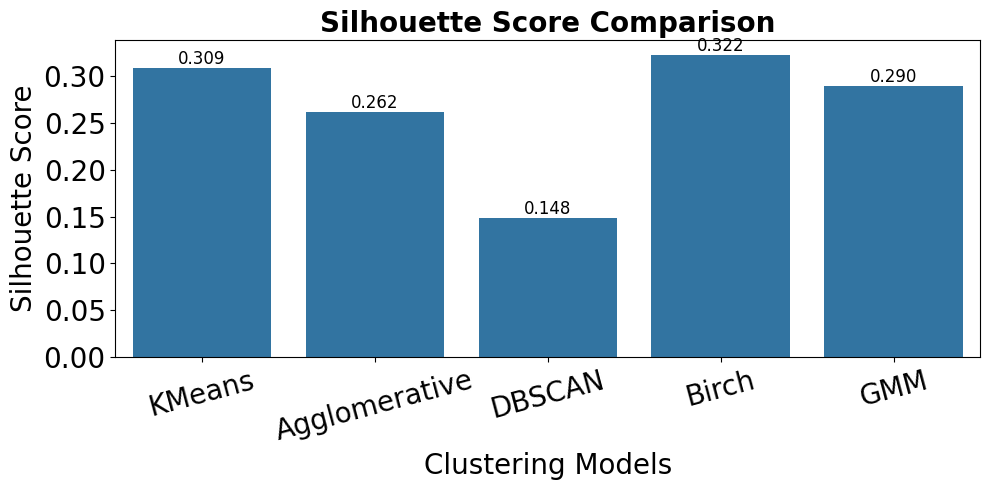

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x='Model',
    y='Silhouette',
    data=results_df
)

plt.title('Silhouette Score Comparison',
          fontsize=20,
          fontweight='bold')

plt.xlabel('Clustering Models',
           fontsize=20)

plt.ylabel('Silhouette Score',
           fontsize=20)

plt.xticks(fontsize=20, rotation=15)
plt.yticks(fontsize=20)

# Add score values above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center',
                va='bottom',
                fontsize=12)

plt.tight_layout()

plt.savefig('Silhouette_Score1.png',
            dpi=600,
            bbox_inches='tight')

plt.show()

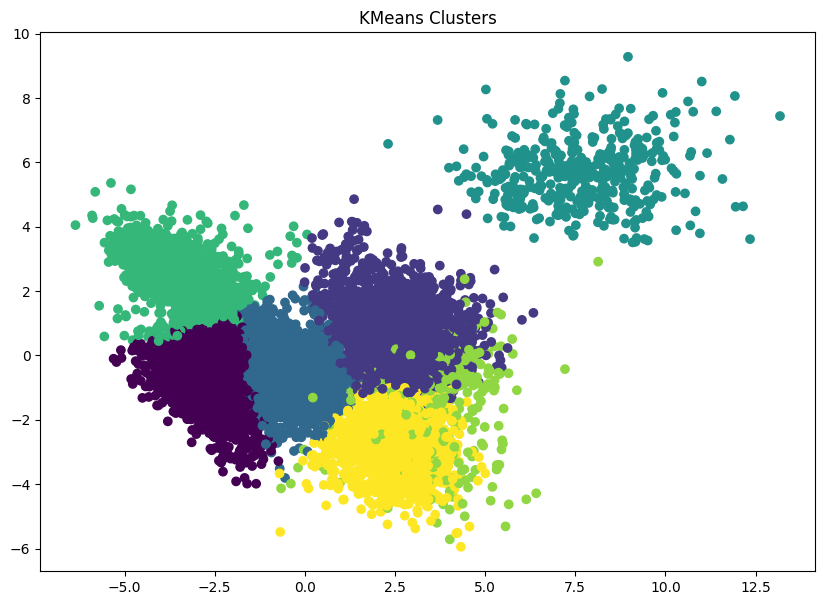

In [ ]:
train_pca = PCA(n_components=7)

X_train_pca = train_pca.fit_transform(X_train)

plt.figure(figsize=(10,7))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.title("KMeans Clusters")
plt.show()

In [ ]:
joblib.dump(
    kmeans,
    "best_kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [ ]:
test_clusters = kmeans.predict(X_test)

print(test_clusters[:20])

[4 5 4 4 0 4 1 4 3 0 0 2 2 6 0 3 0 2 1 0]


In [ ]:
# KMeans without PCA
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

labels_no_pca = kmeans.fit_predict(X_scaled)

In [ ]:
# Without PCA
kmeans_no_pca = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

labels_no_pca = kmeans_no_pca.fit_predict(X_scaled)

# With PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

labels_pca = kmeans_pca.fit_predict(X_pca)

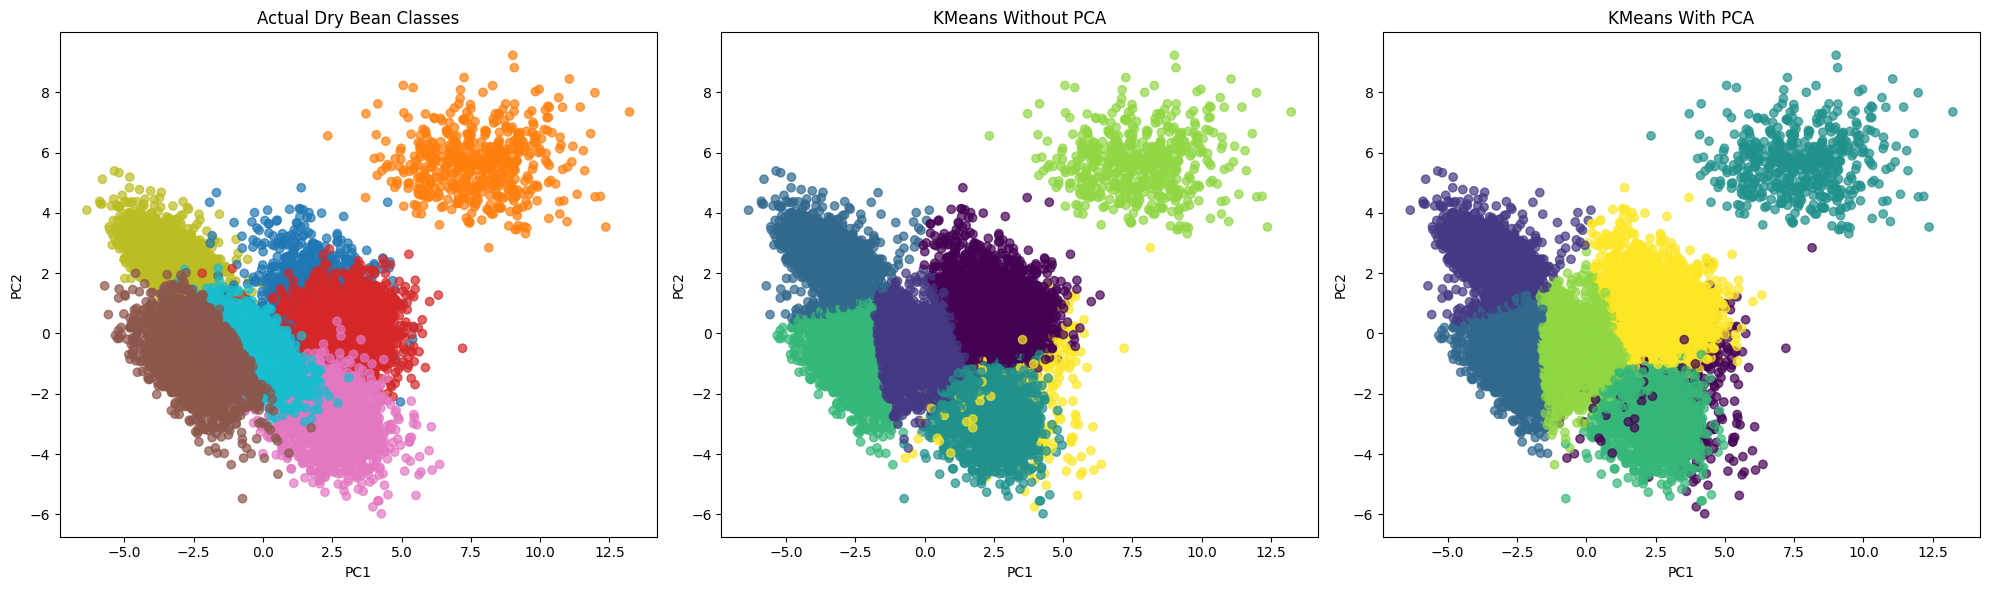

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 2D PCA only for visualization
pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X_scaled)

# Actual labels encoding
le = LabelEncoder()
actual_labels = le.fit_transform(df['Class'])

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# -------------------------
# Actual Classes
# -------------------------
sc1 = axes[0].scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=actual_labels,
    cmap='tab10',
    alpha=0.7
)

axes[0].set_title("Actual Dry Bean Classes")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# -------------------------
# KMeans Without PCA
# -------------------------
sc2 = axes[1].scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=labels_no_pca,
    cmap='viridis',
    alpha=0.7
)

axes[1].set_title("KMeans Without PCA")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# -------------------------
# KMeans With PCA
# -------------------------
sc3 = axes[2].scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=labels_pca,
    cmap='viridis',
    alpha=0.7
)

axes[2].set_title("KMeans With PCA")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")

plt.tight_layout()
plt.show()

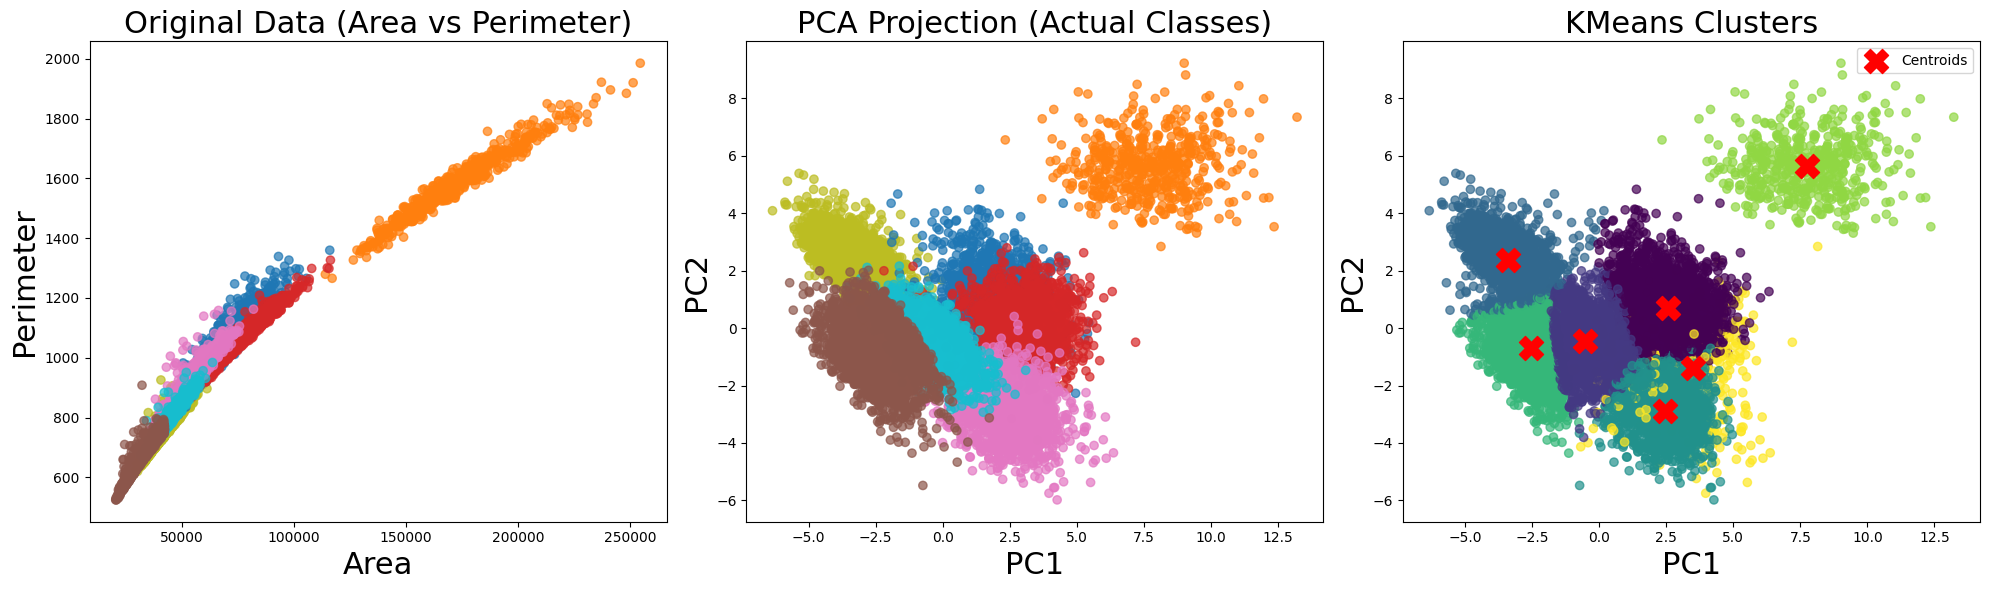

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# -----------------------------
# Features and Labels
# -----------------------------
X = df.drop('Class', axis=1)
y = df['Class']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode actual classes for coloring
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# KMeans
# -----------------------------
kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ====================================
# Plot 1 : Original Data (No PCA)
# ====================================
axes[0].scatter(
    df['Area'],
    df['Perimeter'],
    c=y_encoded,
    cmap='tab10',
    alpha=0.7
)

axes[0].set_title("Original Data (Area vs Perimeter)",fontsize=22)
axes[0].set_xlabel("Area",fontsize=22)
axes[0].set_ylabel("Perimeter",fontsize=22)

# ====================================
# Plot 2 : PCA Projection
# ====================================
axes[1].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_encoded,
    cmap='tab10',
    alpha=0.7
)

axes[1].set_title("PCA Projection (Actual Classes)",fontsize=22)
axes[1].set_xlabel("PC1",fontsize=22)
axes[1].set_ylabel("PC2",fontsize=22)

# ====================================
# Plot 3 : KMeans Clusters
# ====================================
axes[2].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap='viridis',
    alpha=0.7
)

# Plot centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

axes[2].scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='X',
    s=300,
    c='red',
    label='Centroids'
)

axes[2].set_title("KMeans Clusters", fontsize=22)
axes[2].set_xlabel("PC1", fontsize=22)
axes[2].set_ylabel("PC2",fontsize=22)
axes[2].legend()

plt.tight_layout()
plt.savefig('dry_bean_kmeans.png', dpi=600, bbox_inches='tight')
plt.show()

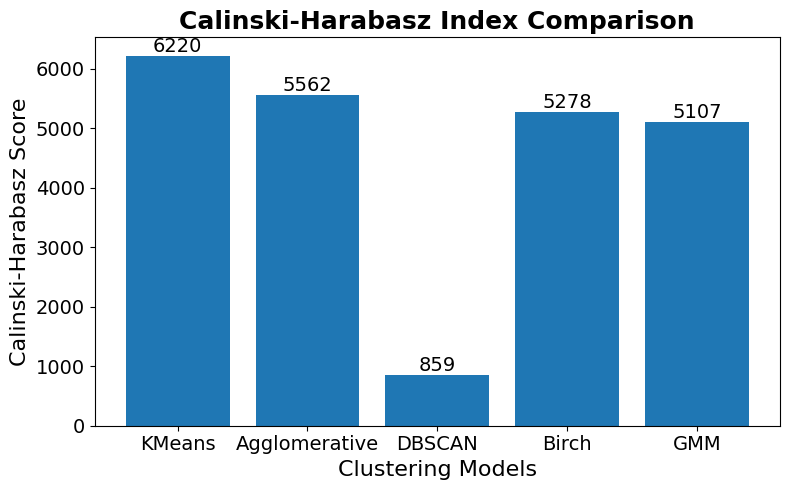

In [ ]:
import matplotlib.pyplot as plt

models = ['KMeans', 'Agglomerative', 'DBSCAN', 'Birch', 'GMM']
ch_scores = [6219.925181, 5562.257751, 858.783035, 5277.531610, 5107.094208]

plt.figure(figsize=(8,5))
bars = plt.bar(models, ch_scores)

plt.title('Calinski-Harabasz Index Comparison', fontsize=18, fontweight='bold')
plt.xlabel('Clustering Models', fontsize=16)
plt.ylabel('Calinski-Harabasz Score', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y,
             f'{y:.0f}', ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.savefig('Calinski_Harabasz_Comparison1.png',
            dpi=600, bbox_inches='tight')
plt.show()

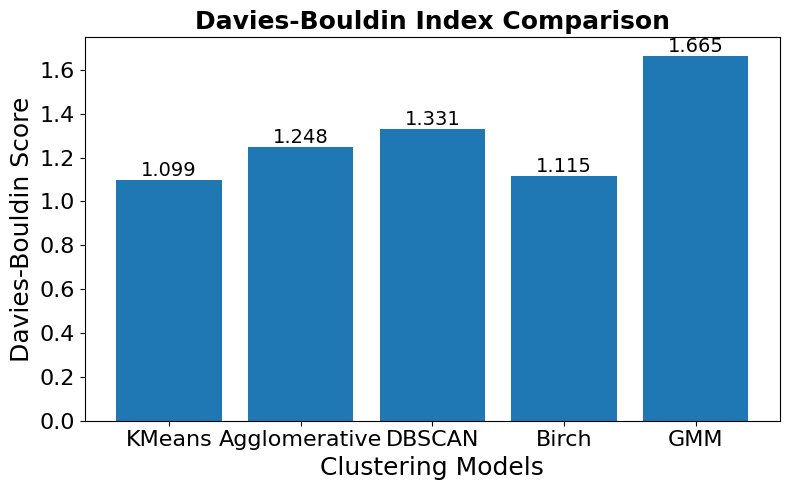

In [ ]:
import matplotlib.pyplot as plt

models = ['KMeans', 'Agglomerative', 'DBSCAN', 'Birch', 'GMM']
db_scores = [1.099351, 1.247731, 1.330565, 1.115049, 1.665191]

plt.figure(figsize=(8,5))
bars = plt.bar(models, db_scores)

plt.title('Davies-Bouldin Index Comparison', fontsize=18, fontweight='bold')
plt.xlabel('Clustering Models', fontsize=18)
plt.ylabel('Davies-Bouldin Score', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y,
             f'{y:.3f}', ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.savefig('Davies_Bouldin_Comparison1.png',
            dpi=600, bbox_inches='tight')
plt.show()

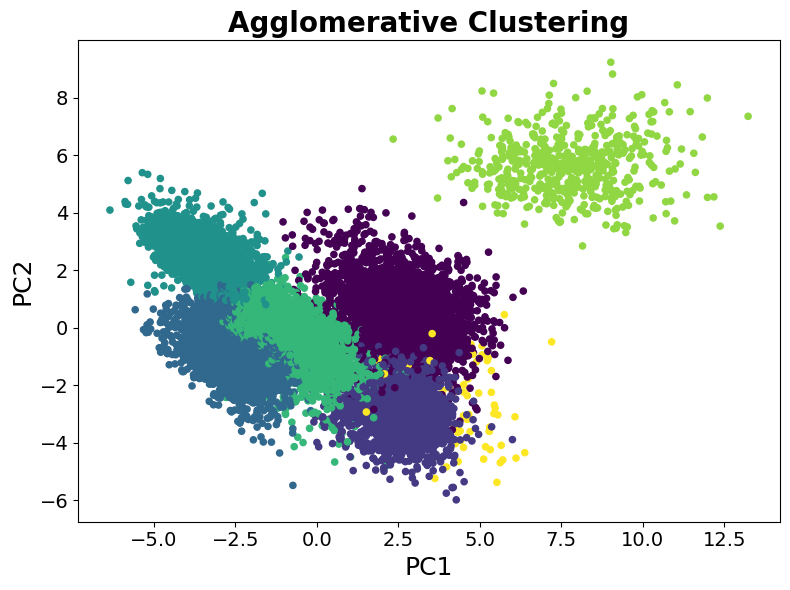

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=7)
agg_labels = agg.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=agg_labels, cmap='viridis', s=20)

plt.title('Agglomerative Clustering', fontsize=20, fontweight='bold')
plt.xlabel('PC1', fontsize=18)
plt.ylabel('PC2', fontsize=18)
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('Agglomerative_Clustering.png',
            dpi=600, bbox_inches='tight')
plt.show()

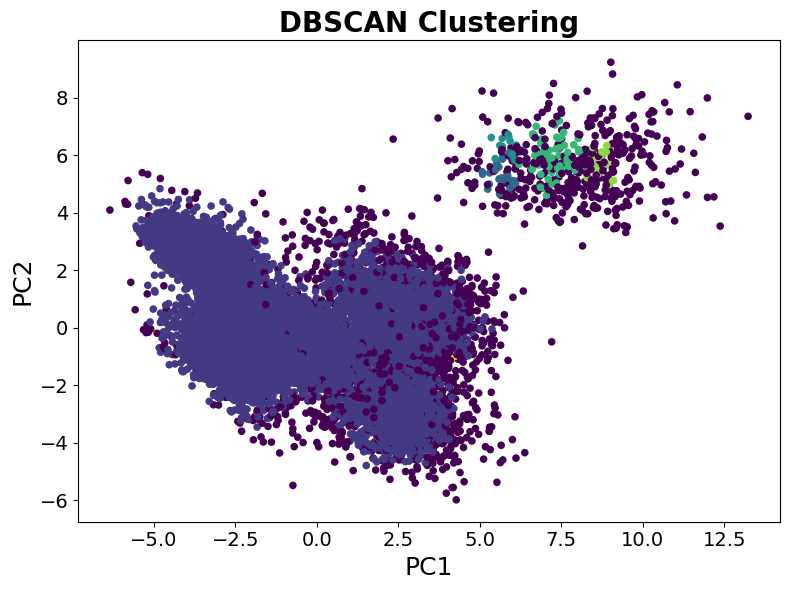

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=db_labels, cmap='viridis', s=20)

plt.title('DBSCAN Clustering', fontsize=20, fontweight='bold')
plt.xlabel('PC1', fontsize=18)
plt.ylabel('PC2', fontsize=18)
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('DBSCAN_Clustering.png',
            dpi=600, bbox_inches='tight')
plt.show()

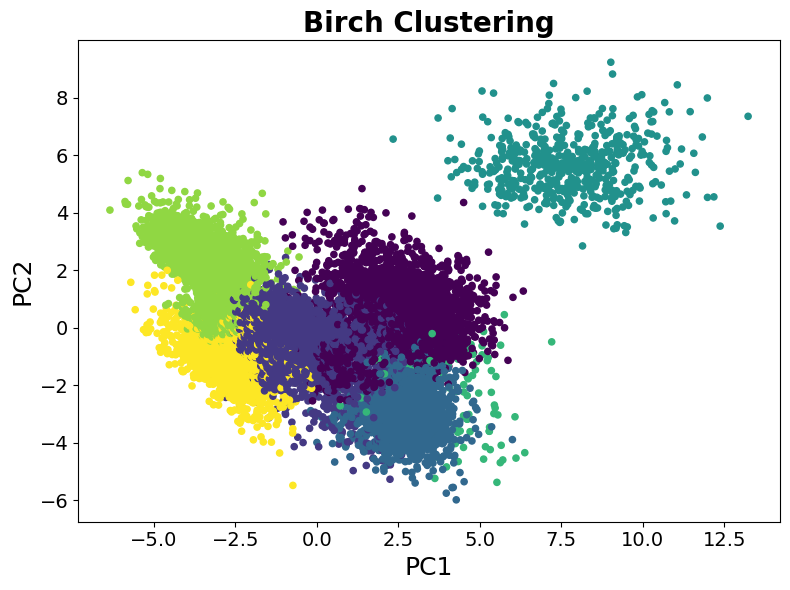

In [ ]:
from sklearn.cluster import Birch

birch = Birch(n_clusters=7)
birch_labels = birch.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=birch_labels, cmap='viridis', s=20)

plt.title('Birch Clustering', fontsize=20, fontweight='bold')
plt.xlabel('PC1', fontsize=18)
plt.ylabel('PC2', fontsize=18)
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('Birch_Clustering.png',
            dpi=600, bbox_inches='tight')
plt.show()

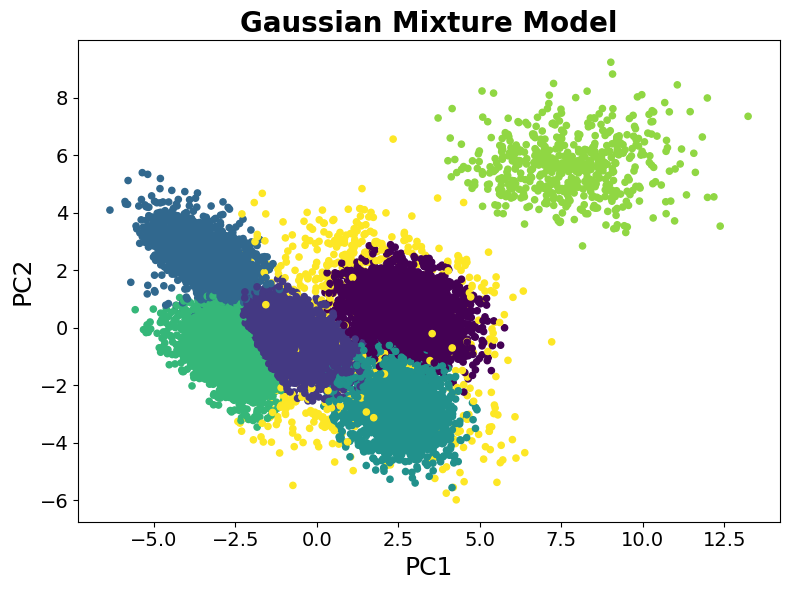

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=7, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=gmm_labels, cmap='viridis', s=20)

plt.title('Gaussian Mixture Model', fontsize=20, fontweight='bold')
plt.xlabel('PC1', fontsize=18)
plt.ylabel('PC2', fontsize=18)
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('GMM_Clustering.png',
            dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

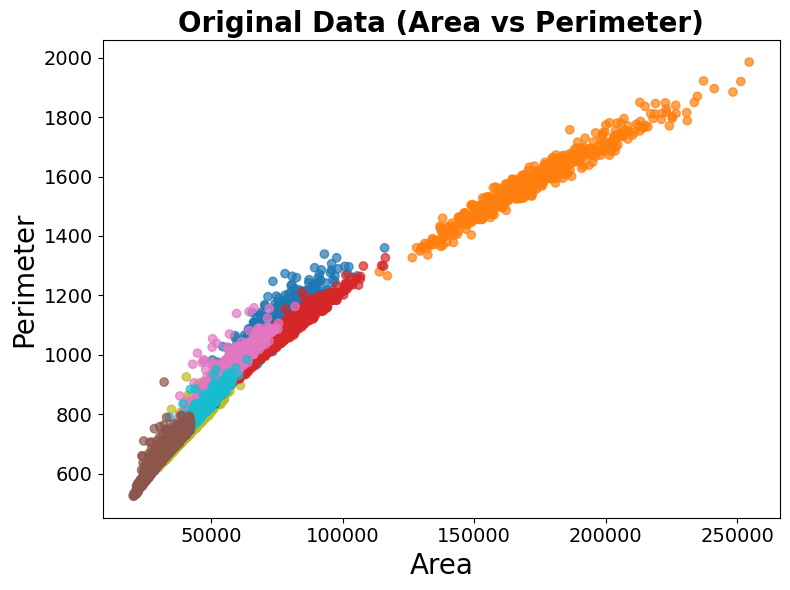

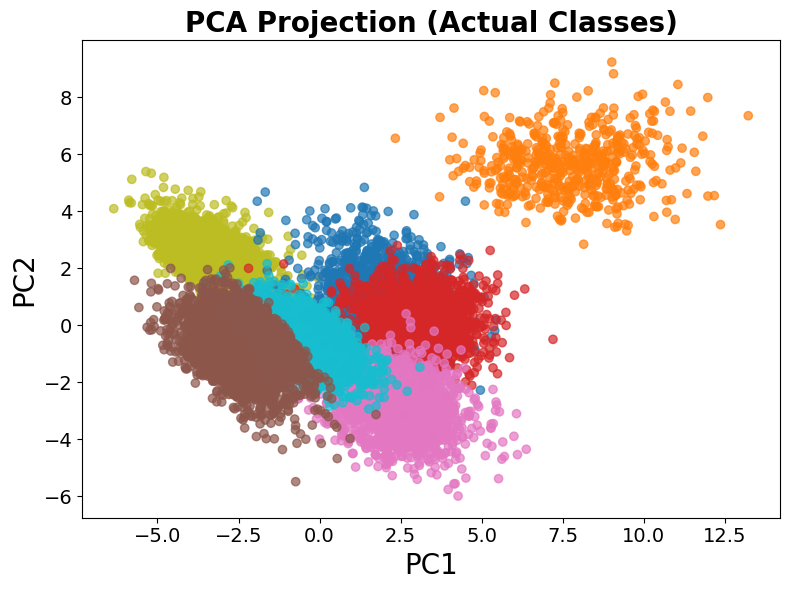

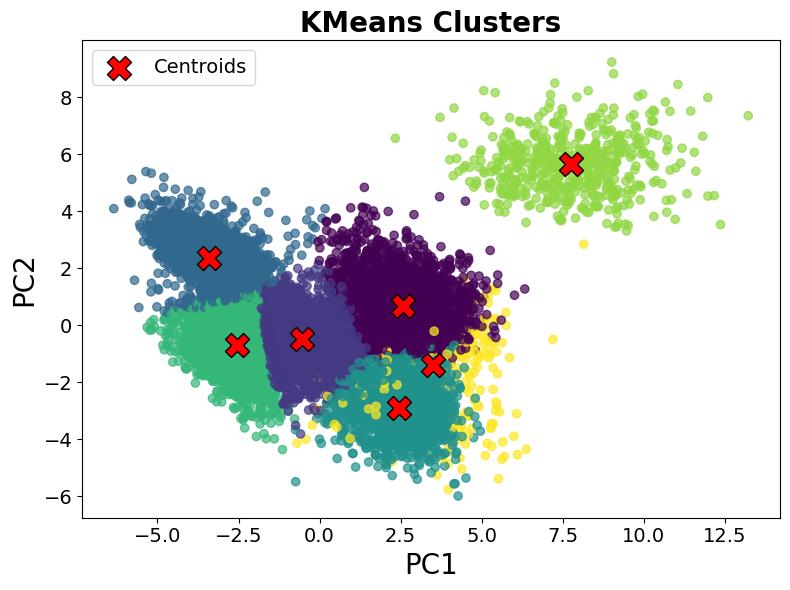

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# -----------------------------
# Features and Labels
# -----------------------------
X = df.drop('Class', axis=1)
y = df['Class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode class labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# KMeans
# -----------------------------
kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# =====================================================
# Figure 1: Original Data (Area vs Perimeter)
# =====================================================
plt.figure(figsize=(8,6))

plt.scatter(
    df['Area'],
    df['Perimeter'],
    c=y_encoded,
    cmap='tab10',
    alpha=0.7
)

plt.title('Original Data (Area vs Perimeter)',
          fontsize=20,
          fontweight='bold')

plt.xlabel('Area', fontsize=20)
plt.ylabel('Perimeter', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()

plt.savefig(
    'Fig1_Original_Data.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


# =====================================================
# Figure 2: PCA Projection (Actual Classes)
# =====================================================
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_encoded,
    cmap='tab10',
    alpha=0.7
)

plt.title('PCA Projection (Actual Classes)',
          fontsize=20,
          fontweight='bold')

plt.xlabel('PC1', fontsize=20)
plt.ylabel('PC2', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()

plt.savefig(
    'Fig2_PCA_Projection.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


# =====================================================
# Figure 3: KMeans Clusters
# =====================================================
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap='viridis',
    alpha=0.7
)

# Centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='X',
    s=300,
    c='red',
    edgecolors='black',
    label='Centroids'
)

plt.title('KMeans Clusters',
          fontsize=20,
          fontweight='bold')

plt.xlabel('PC1', fontsize=20)
plt.ylabel('PC2', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)

plt.tight_layout()

plt.savefig(
    'Fig3_KMeans_Clusters.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

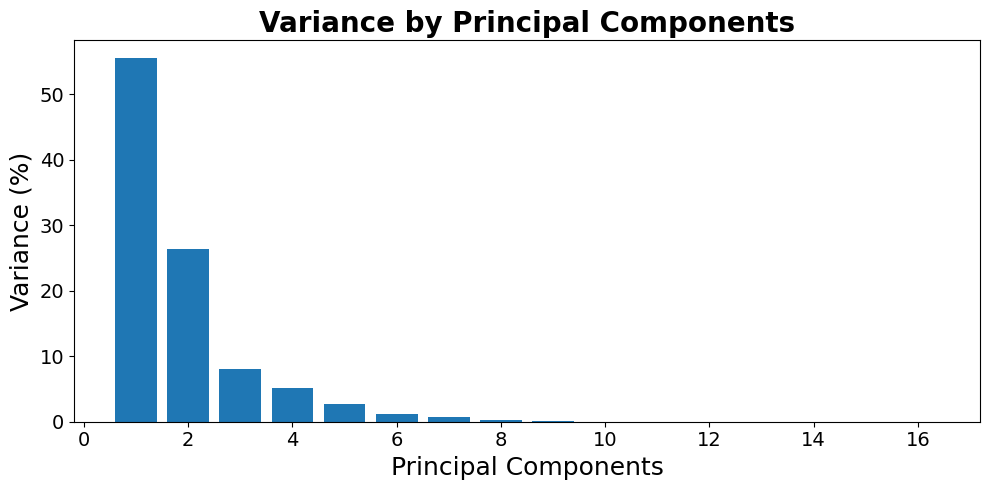

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA on all components
pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))

plt.bar(range(1, len(explained_var)+1),
        explained_var*100)

plt.title('Variance by Principal Components',
          fontsize=20,
          fontweight='bold')

plt.xlabel('Principal Components',
           fontsize=18)

plt.ylabel('Variance (%)',
           fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()

plt.savefig('PCA_Explained_Variance1.png',
            dpi=600,
            bbox_inches='tight')

plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
import pandas as pd

# ---------------------------
# PCA with 4 components
# ---------------------------
pca4 = PCA(n_components=4, random_state=42)
X_pca4 = pca4.fit_transform(X_scaled)

kmeans4 = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

labels4 = kmeans4.fit_predict(X_pca4)

# ---------------------------
# PCA with 5 components
# ---------------------------
pca5 = PCA(n_components=5, random_state=42)
X_pca5 = pca5.fit_transform(X_scaled)

kmeans5 = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

labels5 = kmeans5.fit_predict(X_pca5)

# ---------------------------
# Metrics
# ---------------------------
results = pd.DataFrame({
    'Components':[4,5],
    'Silhouette':[
        silhouette_score(X_pca4, labels4),
        silhouette_score(X_pca5, labels5)
    ],
    'Calinski_Harabasz':[
        calinski_harabasz_score(X_pca4, labels4),
        calinski_harabasz_score(X_pca5, labels5)
    ],
    'Davies_Bouldin':[
        davies_bouldin_score(X_pca4, labels4),
        davies_bouldin_score(X_pca5, labels5)
    ]
})

print(results)

   Components  Silhouette  Calinski_Harabasz  Davies_Bouldin
0           4    0.327712        9134.223171        1.032761
1           5    0.310543        8173.809777        1.091732


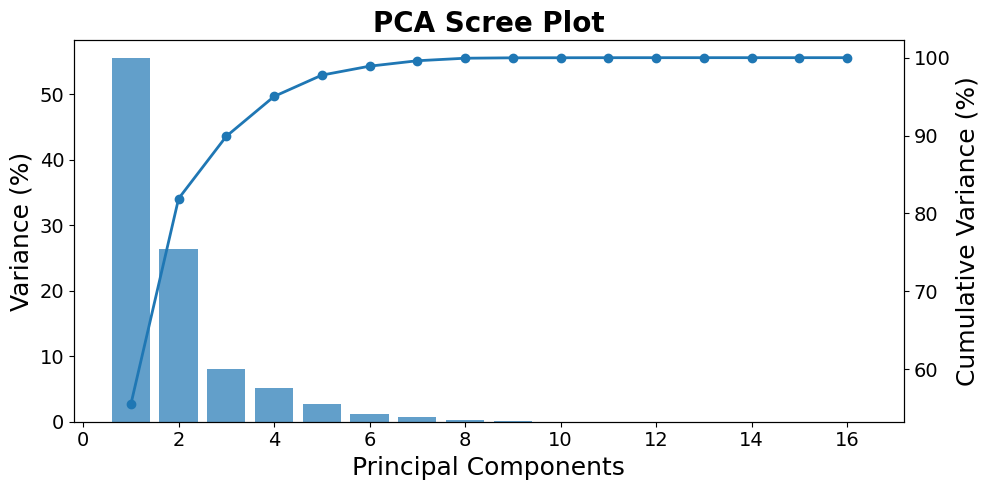

In [ ]:
import numpy as np

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(range(1, len(explained_var)+1),
        explained_var*100,
        alpha=0.7,
        label='Individual Variance')

ax1.set_xlabel('Principal Components', fontsize=18)
ax1.set_ylabel('Variance (%)', fontsize=18)
ax1.tick_params(axis='both', labelsize=14)

ax2 = ax1.twinx()

ax2.plot(range(1, len(cum_var)+1),
         cum_var*100,
         marker='o',
         linewidth=2)

ax2.set_ylabel('Cumulative Variance (%)',
               fontsize=18)

ax2.tick_params(axis='y', labelsize=14)

plt.title('PCA Scree Plot',
          fontsize=20,
          fontweight='bold')

plt.tight_layout()

plt.savefig('PCA_Scree_Plot.png',
            dpi=600,
            bbox_inches='tight')

plt.show()

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_scaled)

# Variance explained by first 7 PCs
first7_var = np.sum(pca.explained_variance_ratio_[:4])

print("Variance explained by first 7 PCs:", first7_var)
print("Percentage:", first7_var * 100)

Variance explained by first 7 PCs: 0.9501805632934499
Percentage: 95.01805632934499


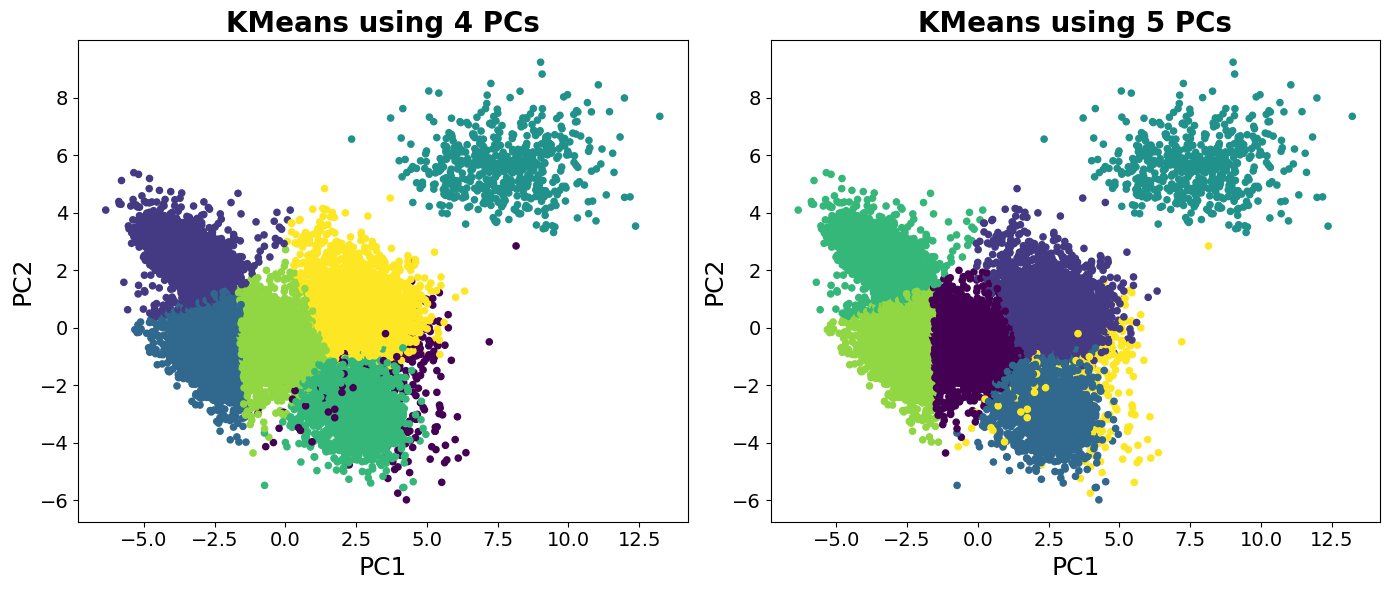

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(14,6))

# PCA = 4
axes[0].scatter(
    X_pca4[:,0],
    X_pca4[:,1],
    c=labels4,
    cmap='viridis',
    s=20
)

axes[0].set_title(
    'KMeans using 4 PCs',
    fontsize=20,
    fontweight='bold'
)

axes[0].set_xlabel('PC1', fontsize=18)
axes[0].set_ylabel('PC2', fontsize=18)

# PCA = 5
axes[1].scatter(
    X_pca5[:,0],
    X_pca5[:,1],
    c=labels5,
    cmap='viridis',
    s=20
)

axes[1].set_title(
    'KMeans using 5 PCs',
    fontsize=20,
    fontweight='bold'
)

axes[1].set_xlabel('PC1', fontsize=18)
axes[1].set_ylabel('PC2', fontsize=18)

for ax in axes:
    ax.tick_params(labelsize=14)

plt.tight_layout()

plt.savefig(
    'KMeans_4PC_vs_5PC.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

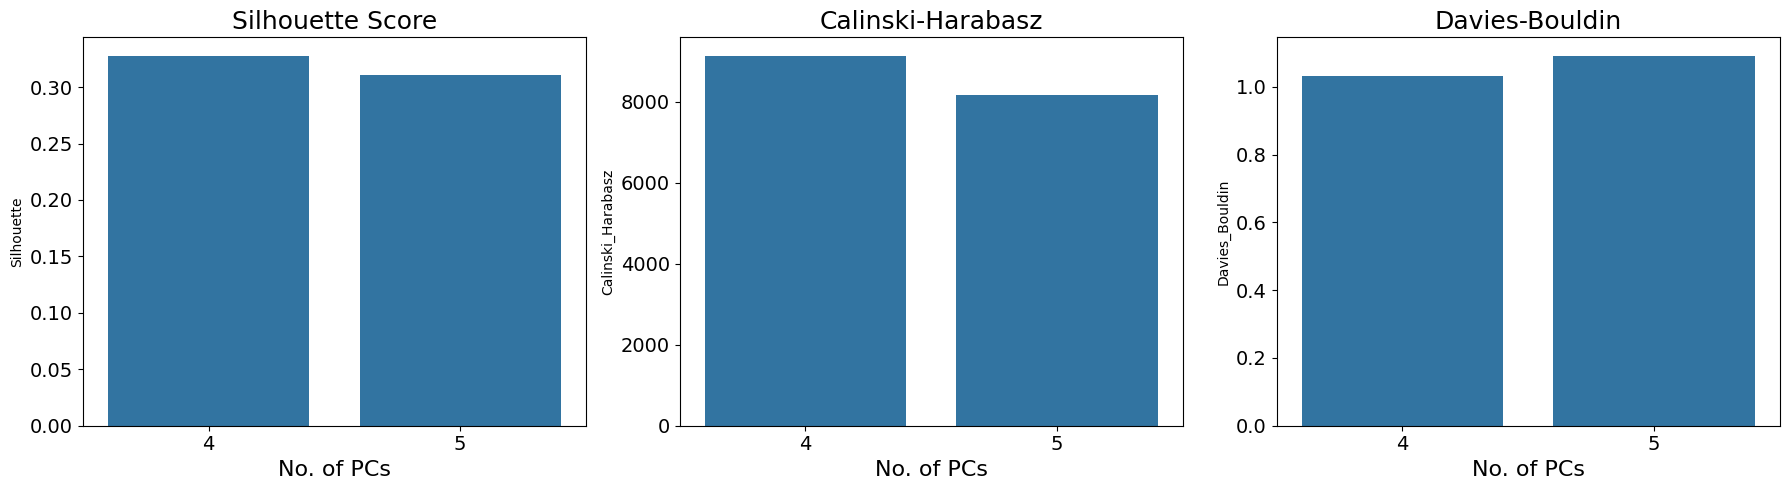

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.barplot(
    x='Components',
    y='Silhouette',
    data=results,
    ax=axes[0]
)

axes[0].set_title('Silhouette Score', fontsize=18)

sns.barplot(
    x='Components',
    y='Calinski_Harabasz',
    data=results,
    ax=axes[1]
)

axes[1].set_title('Calinski-Harabasz', fontsize=18)

sns.barplot(
    x='Components',
    y='Davies_Bouldin',
    data=results,
    ax=axes[2]
)

axes[2].set_title('Davies-Bouldin', fontsize=18)

for ax in axes:
    ax.set_xlabel('No. of PCs', fontsize=16)
    ax.tick_params(labelsize=14)

plt.tight_layout()

plt.savefig(
    '4PC_vs_5PC_Metrics.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()